## Dataset Structure Inspection

The retinal OCT dataset was accessed using the absolute project path to avoid ambiguity in relative directory resolution. This verification step confirms that the extracted dataset is reachable and that the expected split folders are available for subsequent analysis.

In [1]:
from pathlib import Path

# The dataset root is defined using the confirmed absolute path so that the notebook can access the extracted files reliably.
dataset_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017")

# The existence of the dataset directory is checked before inspecting its contents.
print("Dataset root exists:", dataset_root.exists())

# The top-level folders are listed to verify the available dataset splits.
print("\nTop-level contents:")
for item in dataset_root.iterdir():
    print("-", item.name)

Dataset root exists: True

Top-level contents:
- OCT2017
- test
- train
- val


## Class Distribution Across Available Splits

The number of retinal OCT images in each class was computed separately for the available dataset splits. This provides an initial view of class balance and helps identify whether imbalance may affect model training and evaluation.

In [2]:
from pathlib import Path

# A helper function is defined to count valid image files inside each class directory.
def count_images(folder: Path):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in valid_exts)

# The confirmed dataset root is reused so that the split-wise inspection remains consistent.
dataset_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017")

print("Image counts by split and class:")

# The available train and test directories are traversed to report class counts.
for split in ["train", "test"]:
    split_path = dataset_root / split
    if split_path.exists():
        print(f"\n[{split}]")
        for class_dir in split_path.iterdir():
            if class_dir.is_dir():
                image_count = count_images(class_dir)
                print(f"{class_dir.name}: {image_count}")

Image counts by split and class:

[train]
CNV: 37205
DME: 11348
DRUSEN: 8616
NORMAL: 26315

[test]
CNV: 242
DME: 242
DRUSEN: 242
NORMAL: 242


## Visualisation of Training Set Class Distribution

The class distribution within the training set was visualised to highlight the relative number of samples available for each retinal condition. This representation supports an early assessment of dataset imbalance.

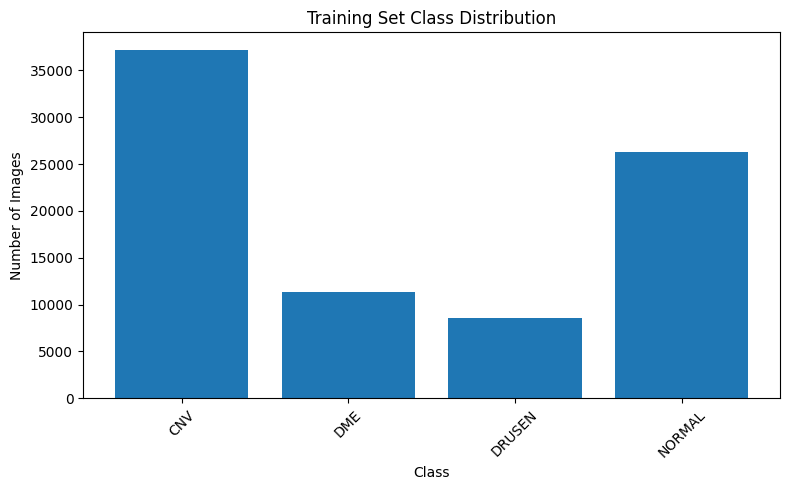

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path

# The training directory is selected so that the class-wise image counts can be visualised.
train_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017\train")

class_counts = {}

# The number of images in each training class is collected for plotting.
for class_dir in train_root.iterdir():
    if class_dir.is_dir():
        image_count = sum(1 for p in class_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"})
        class_counts[class_dir.name] = image_count

# A bar chart is produced to present the training set distribution across retinal classes.
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sample Image Visualisation

Representative retinal OCT scans from each class were displayed to examine the visual appearance of the dataset. This step also confirms that the image files are loaded correctly before preprocessing and model training.

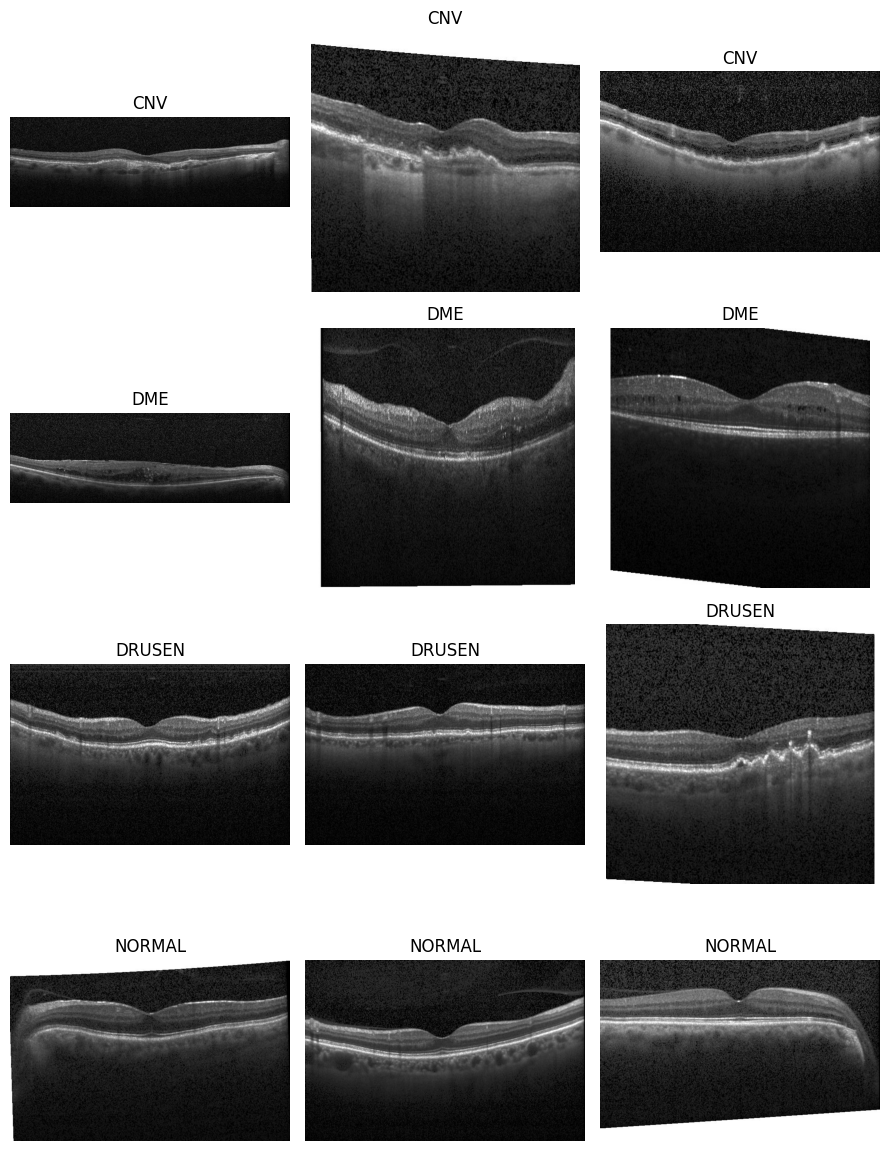

In [4]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# The training directory is used as the source of representative class samples.
train_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017\train")

# The available class folders are collected for class-wise visual inspection.
class_dirs = [p for p in train_root.iterdir() if p.is_dir()]

fig, axes = plt.subplots(len(class_dirs), 3, figsize=(9, 3 * len(class_dirs)))

# A small set of random images is drawn from each class to provide a qualitative overview of the data.
for row, class_dir in enumerate(class_dirs):
    image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
    selected_images = random.sample(image_paths, min(3, len(image_paths)))

    for col in range(3):
        ax = axes[row, col]
        ax.axis("off")

        if col < len(selected_images):
            image = Image.open(selected_images[col]).convert("L")
            ax.imshow(image, cmap="gray")
            ax.set_title(class_dir.name)

plt.tight_layout()
plt.show()

## Initial Observations

The dataset is organised into separate training and testing directories, with class labels corresponding to different retinal conditions. The training set exhibits a noticeable class imbalance, with CNV and NORMAL classes having significantly more samples compared to DME and DRUSEN. This imbalance may influence model learning and bias predictions toward majority classes.

In contrast, the test set is evenly distributed across all classes, which provides a fair basis for evaluating model performance. Visual inspection of sample images indicates that certain classes share similar structural patterns, which may increase the difficulty of classification and require more expressive models.

## Dataset Summary

A summary of the dataset distribution is presented below to provide a concise overview of the number of samples in each class across training and testing sets.

In [5]:
import pandas as pd

# The previously computed class counts are manually structured into a table for clarity.
data = {
    "Class": ["CNV", "DME", "DRUSEN", "NORMAL"],
    "Train": [37205, 11348, 8616, 26315],
    "Test": [242, 242, 242, 242],
}

df = pd.DataFrame(data)

# The table is displayed to summarise the dataset composition.
df

,Class,Train,Test
0,CNV,37205,242
1,DME,11348,242
2,DRUSEN,8616,242
3,NORMAL,26315,242


### Report Note

The presence of class imbalance in the training data suggests that evaluation metrics beyond accuracy, such as precision, recall, and F1-score, will be necessary to properly assess model performance.

## Dataset Interpretation

The dataset summary confirms a substantial imbalance in the training set. The CNV class contains the largest number of training samples, followed by NORMAL, while DME and DRUSEN are represented by noticeably fewer examples. Such imbalance may bias model learning toward majority classes and therefore motivates the use of class-sensitive evaluation metrics during model assessment.

In contrast, the test set is evenly distributed across all four classes, which provides a balanced and more reliable basis for final evaluation. This separation between an imbalanced training set and a balanced test set is useful, as it allows the models to be trained on realistic data variation while still being assessed fairly across categories.

## Transition to Preprocessing and Data Loading

The dataset structure, class distribution, and visual characteristics have now been inspected successfully. The next stage of the workflow will focus on constructing a preprocessing pipeline, creating a validation split from the training data, and preparing PyTorch dataloaders for model development.